Парная линейная регрессия
Цель работы
    Познакомиться с моделью парной линейной регрессии регрессии и методом градиентного спуска.

Содержание работы
Найти оценки параметров модели парной линейной регрессии прямыми вычислениями и палучить с помощью модели прогнозы результативного прознака.
Найти оценки параметров модели парной линейной регрессии с использованием метода градиентного спуска.
Оценить качество построенной модели, сравнив на графике обучающую выборку и прогнозы.
Построить кривые обучения.

In [11]:
#Загрузим необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
#Исходные данные: x - расходы на рекламу, Y - объемы продаж
x = np.array([3, 5, 7, 6, 9])
Y = np.array([3, 7, 11, 14, 15])
display(x, Y)

array([3, 5, 7, 6, 9])

array([ 3,  7, 11, 14, 15])

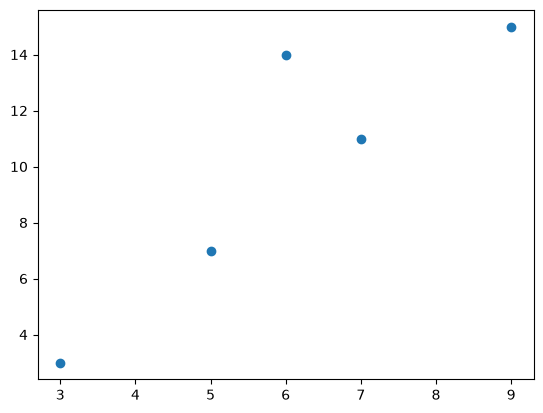

In [13]:
#Изобразим их на графике
plt.figure()
plt.scatter(x, Y)
plt.show()

In [14]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии: Y^ = ", a0, " + ", a1, "* x")

Модель линейной регрессии: Y^ =  -2.0  +  2.0 * x


In [15]:
#Дадим серию прогнозов Y^ для x от 3 до 9 с шагом 1
x_space = np.linspace(3, 9, 7)
print(x_space)
Y_pred = a0 + a1*x_space
print(Y_pred)

[3. 4. 5. 6. 7. 8. 9.]
[ 4.  6.  8. 10. 12. 14. 16.]


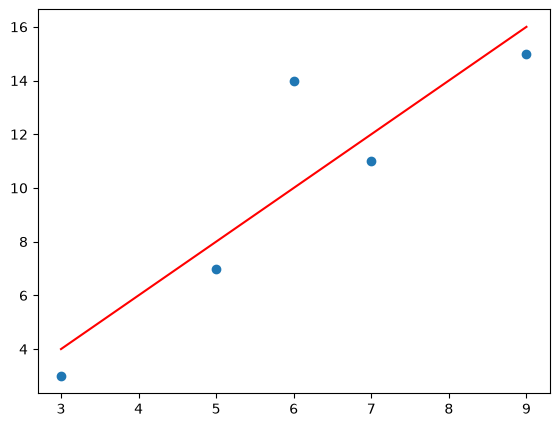

In [ ]:
#Изобразим на графике исходные данные и прогнозы 
fig  = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # type: ignore
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, "r")
#ax.scatter(x_space, Y_pred)

In [17]:
#Реализуем шаг градиентного спуска в модели парной лдинейной регрессии
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((self.predict(x)-Y)**2).mean()
    def fit(self, x, Y):
        alpha = 0.1
        dT_a0 = -2*sum((Y -self.predict(x)))
        dT_a1 = -2*sum((Y -self.predict(x))*x)
        self.a0 -= alpha*dT_a0
        self.a1 -= alpha*dT_a1

In [18]:
#Получим прогнозы до градиентного спуска с начальными значениями параметров
regr = SimpleRegression()
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print(regr.MSE(x, Y))

0
0
0
0
0
120.0


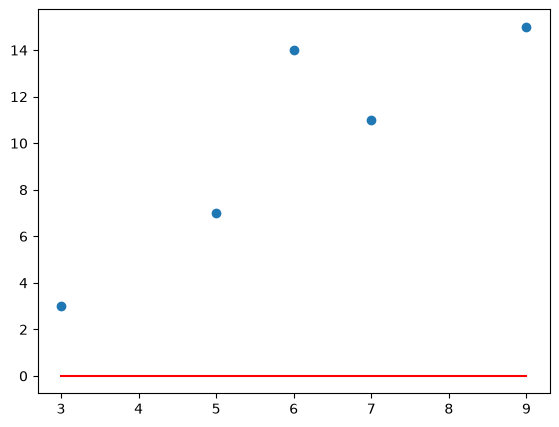

In [ ]:
#Выведем прогнозы до градиентного спуска на графике
x_space = np.linspace(3, 9, 7)
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # type: ignore
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, "r")

MSE после первого шага градиентного спуска:  183892.0


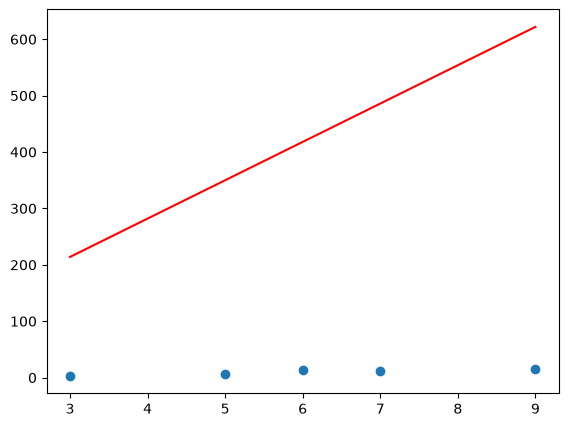

In [ ]:
#Реализуем шаг градиентного спуска
regr.fit(x, Y)
print("MSE после первого шага градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # type: ignore
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, "r")

In [21]:
#Реализуем цикл градиентного спуска
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((Y - self.predict(x))**2).mean()
    def MAE(self, x, Y):
        return abs(Y - self.predict(x)).mean()
    def MAPE(self, x, Y):
        return abs((Y - self.predict(x))/Y).mean()
    def fit(self, x, Y, alpha = 0.001, epsylon = 0.01, max_steps = 5000):
        steps, errors = [], []
        step = 0
        for _ in range(max_steps):
            dT_a0 = -2*sum((Y -self.predict(x)))
            dT_a1 = -2*sum((Y -self.predict(x))*x)
            self.a0 -= alpha*dT_a0
            self.a1 -= alpha*dT_a1
            new_error = self.MSE(x, Y)
            step += 1
            steps.append(step)
            errors.append(new_error)
            if new_error < epsylon:
                break
        return steps, errors

In [22]:
#Запустим цикл градиентного спуска с заданной точностью 5
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 5)

5.004697916218
8.190462542210001
11.376227168202002
9.783344855206002
14.561991794194002
MSE после градиентного спуска:  4.709918696051655


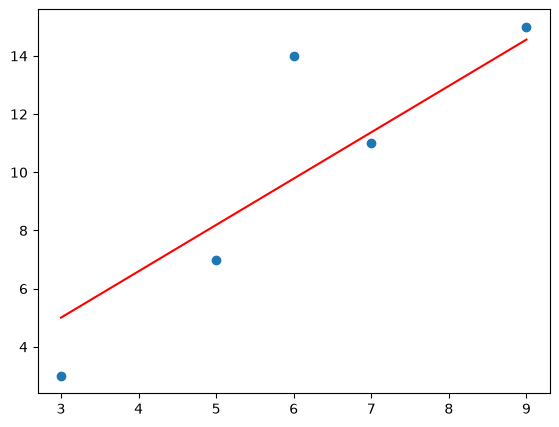

In [ ]:
#Выведем график  прогнозов и вычислим MSE
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # type: ignore
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, "r")

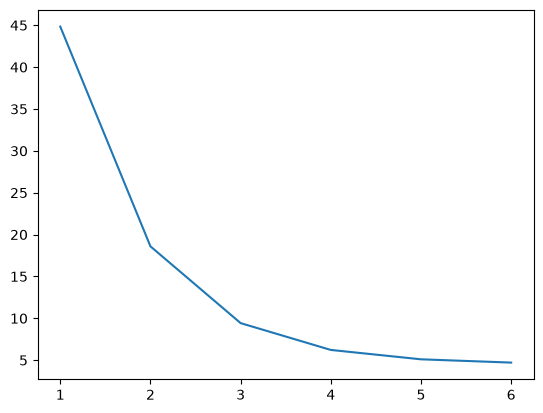

In [24]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

In [25]:
#Запустим цикл градиентного спуска с заданной точностью 0.05
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 0.05)

MSE после градиентного спуска:  4.000028517306817


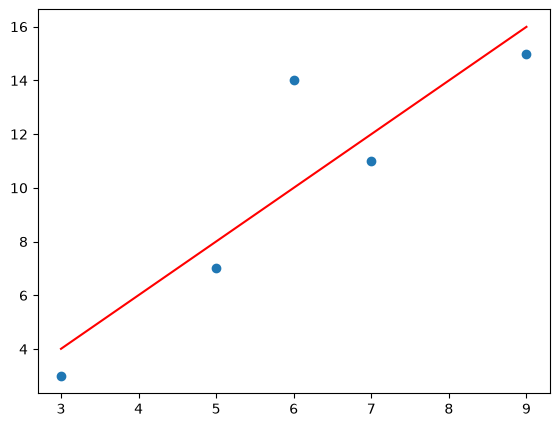

In [ ]:
#Выведем график прогнозов и вычислим MSE
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # type: ignore
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, "r")

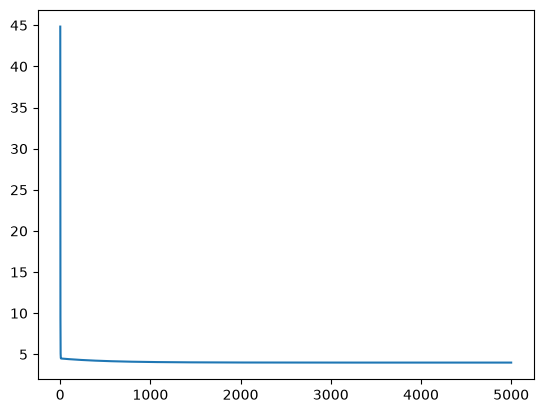

In [27]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

MSE после градиентного спуска:  4.1903709155046345


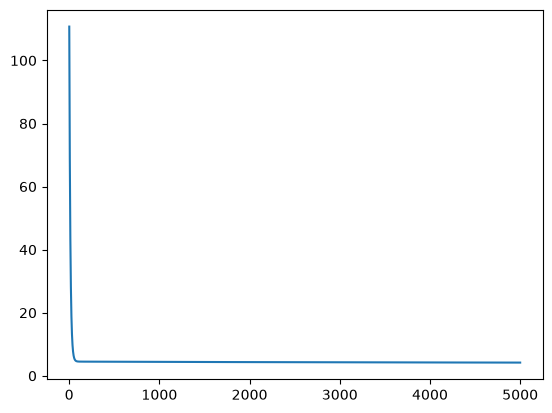

In [28]:
#Запустим цикл градиентного спуска с разными значениями скорости обучения alpha=0.0001, 0.01, 0.1, 1, 10, ..., 
#с различной допукстимой точностью epsylon = 0.001, 0.5, 5, с различным максимальным количеством шагов max_steps
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.0001, epsylon = 0.01, max_steps = 5000)
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
plt.figure()
plt.plot(steps, errors)

Загрузите файл Гиперспектр кукурузы.csv (с помощью pd.read_csv).

1. Вычислите аналитическим путем оценки коэффициентов парной линейной регрессии и постройте ее график.
2. Найдите оценки параметров модели парной лиенйной регрессии с использованием метода градиентного спуска. Постройте график.
3. Оцените качество построенных моделей сравнив на графике обучающую выборку и прогнозы.


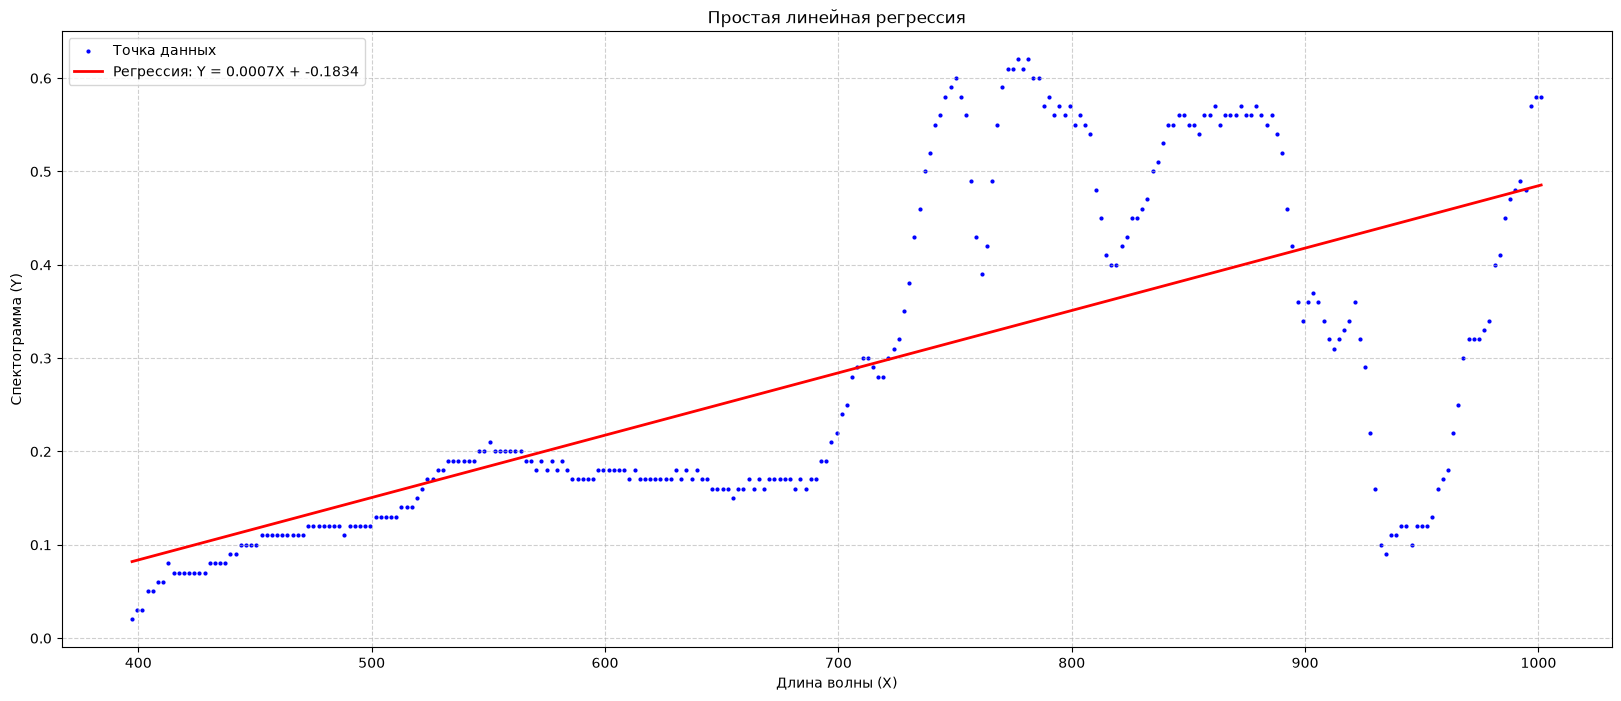

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

gipers = pd.read_csv(r"spectr.csv",sep=";",decimal=",")
X = gipers["wavelength"].to_numpy()
Y = gipers["Spectr"].to_numpy()

mean_X = np.mean(X)
mean_Y = np.mean(Y)

numerator = np.sum((X - mean_X) * (Y - mean_Y))
denominator = np.sum((X - mean_X)**2)

m = numerator / denominator
c = mean_Y - (m * mean_X)

Y_pred = m * X + c
plt.figure(figsize=(20, 8))
plt.scatter(X, Y, color="#0000FF", s=4, label="Точка данных")
plt.plot(X, Y_pred, color="#ff0000", linewidth=2, label=f"Регрессия: Y = {m:.4f}X + {c:.4f}")

plt.xlabel("Длина волны (X)")
plt.ylabel("Спектограмма (Y)")
plt.title("Простая линейная регрессия")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


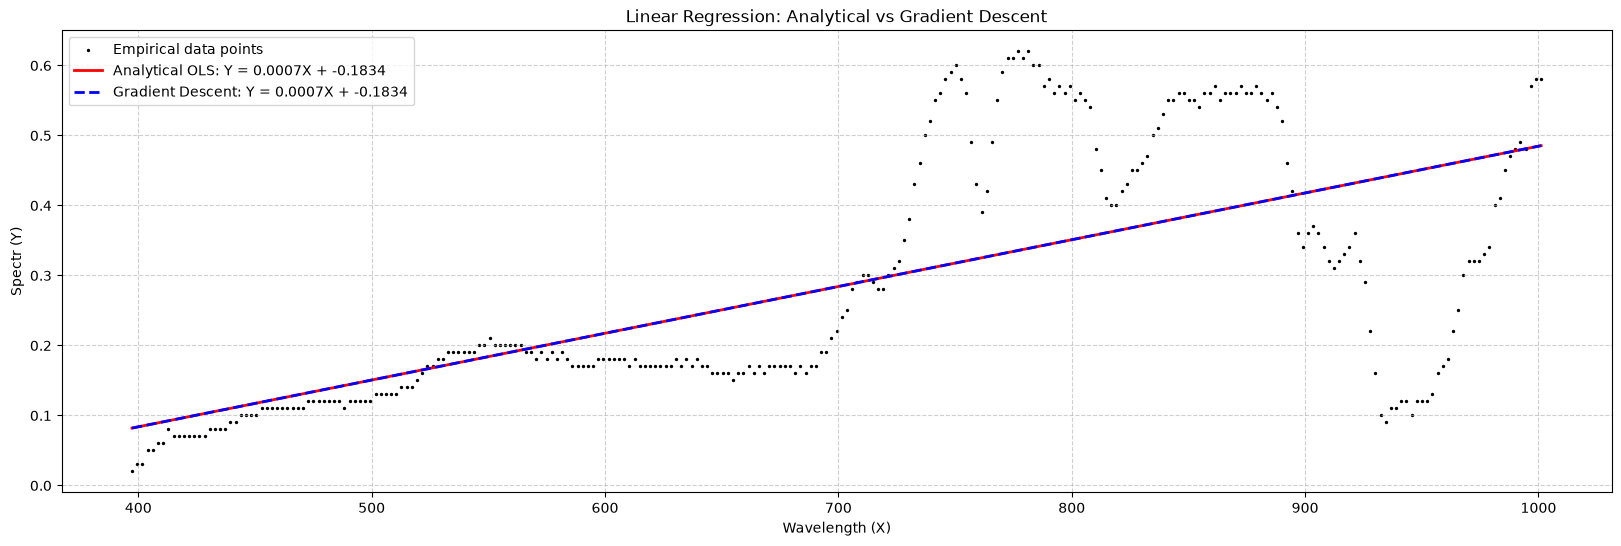

In [ ]:
from typing import Any, Dict, List


class GradientDescent(object):
  def __init__(self,X) -> None:
    self.N = len(Y)

    self.mu_X = np.mean(X)
    self.sigma_X = np.std(X)
    self.X_scaled = (X - self.mu_X) / self.sigma_X

    self.learning_rate = 0.01  # Alpha
    self.epochs = 1000         # Number of iterations

    self.theta_0 = 0.0
    self.theta_1 = 0.0

    self.mse_history: List[int] = []
    
  def descent(self) -> Dict[str, Any]:
    for i in range(self.epochs):
      # Calculate predictions
      Y_pred_scaled = self.theta_0 + (self.theta_1 * self.X_scaled)
      
      # Calculate the error
      error = Y_pred_scaled - Y
      
      # Calculate gradients
      d_theta_0 = (1 / self.N) * np.sum(error)
      d_theta_1 = (1 / self.N) * np.sum(error * self.X_scaled)
      
      # Update parameters simultaneously
      self.theta_0 = self.theta_0 - (self.learning_rate * d_theta_0)
      self.theta_1 = self.theta_1 - (self.learning_rate * d_theta_1)
      
      # Calculate and store current MSE (Cost)
      mse = (1 / (2 * self.N)) * np.sum(error ** 2)
      self.mse_history.append(mse)
    
    m_gd = self.theta_1 / self.sigma_X
    c_gd = self.theta_0 - (self.theta_1 * self.mu_X / self.sigma_X)
    Y_pred_gd = m_gd * X + c_gd
    return {"m_gd": m_gd, "c_gd": c_gd, "Y_pred_gd": Y_pred_gd}
  
reg = GradientDescent(X)
result = reg.descent()
Y_pred_dg = result["Y_pred_gd"]
m_gd = result["m_gd"]
c_gd = result["c_gd"]
mse_history = reg.mse_history

plt.figure(figsize=(20, 6))
plt.scatter(X, Y, color="black", s=2, label="Empirical data points")
plt.plot(X, Y_pred, color="red", linewidth=2, label=f"Analytical OLS: Y = {m:.4f}X + {c:.4f}")
# Plot Gradient Descent line
plt.plot(X, Y_pred_dg, color="blue", linestyle="--", linewidth=2, label=f"Gradient Descent: Y = {m_gd:.4f}X + {c_gd:.4f}")
plt.xlabel("Wavelength (X)")
plt.ylabel("Spectr (Y)")
plt.title("Linear Regression: Analytical vs Gradient Descent")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



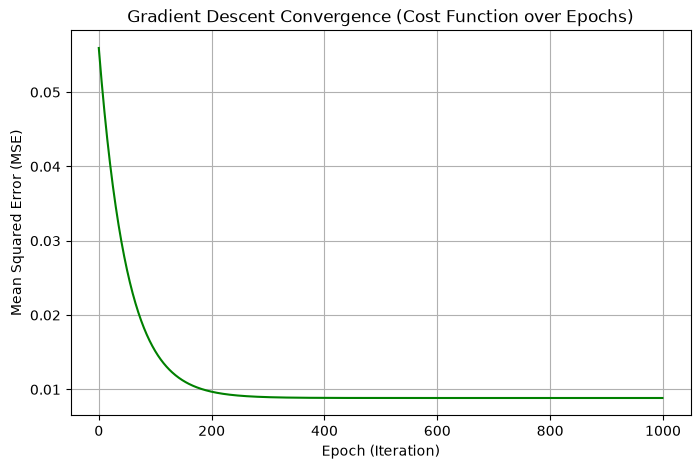

In [ ]:
# 7. Plot MSE Convergence to prove the algorithm successfully minimized the cost function
plt.figure(figsize=(8, 5))
plt.plot(mse_history, color="green")
plt.title("Gradient Descent Convergence (Cost Function over Epochs)")
plt.xlabel("Epoch (Iteration)")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()


    ## Results

    Mean Squared Error (MSE): $0.017684$

    Mean Absolute Error (MAE): $0.096834$

    $R^2$: $0.435891$

    ## Graphs
    

<IPython.core.display.HTML object>

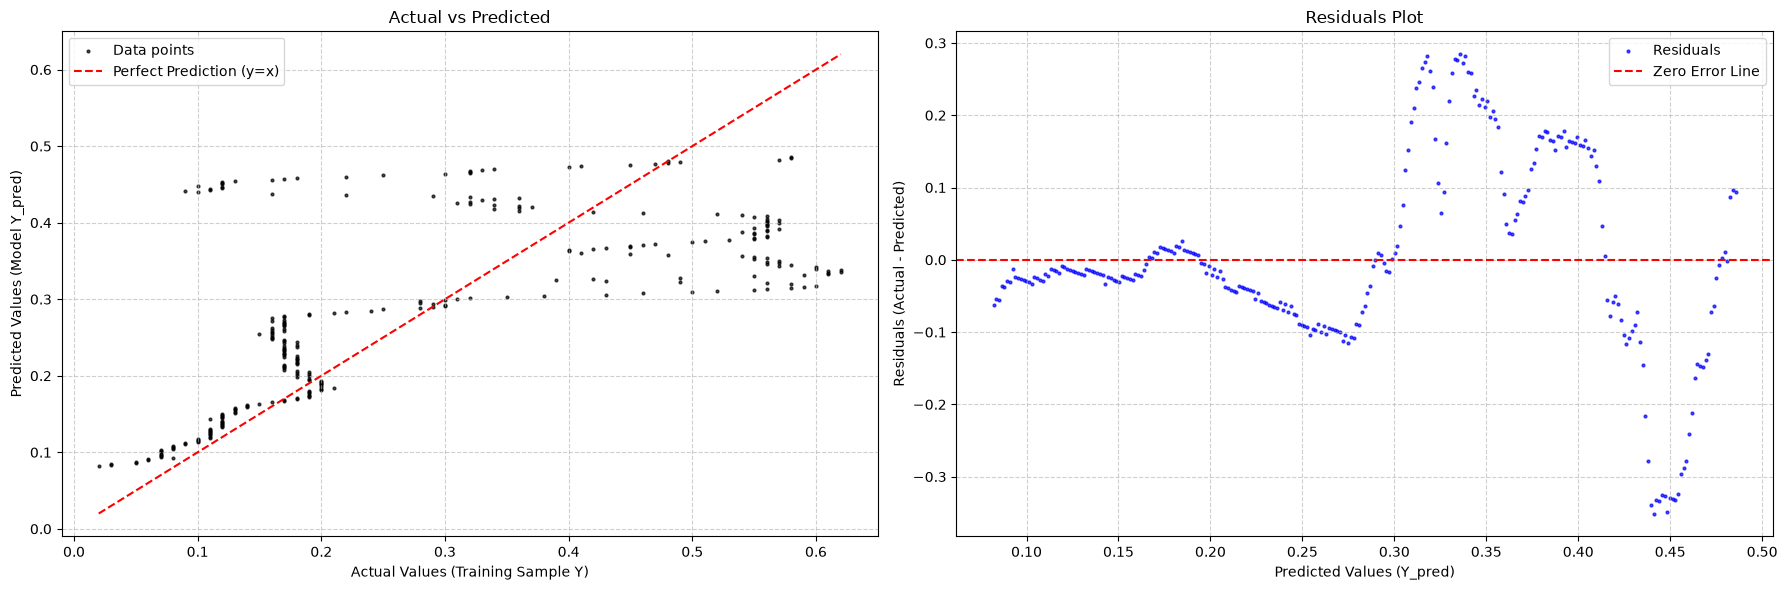

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as d

# 1. Calculate Quantitative Metrics
residuals = Y - Y_pred

# Mean Squared Error (MSE) and Mean Absolute Error (MAE)
mse = np.mean(residuals**2)
mae = np.mean(np.abs(residuals))

# R-squared (Coefficient of Determination)
ss_res = np.sum(residuals**2)           # Sum of squares of residuals
ss_tot = np.sum((Y - np.mean(Y))**2)    # Total sum of squares
r_squared = 1 - (ss_res / ss_tot)

display(Markdown(
  rf"""
    ## Results
    
    Mean Squared Error (MSE): ${mse:.6f}$
    
    Mean Absolute Error (MAE): ${mae:.6f}$
    
    $R^2$: ${r_squared:.6f}$
    
    ## Graphs
  """
))

# 2. Generate Evaluation Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot A: Actual vs Predicted
ax1.scatter(Y, Y_pred, color="black", s=4, alpha=0.7, label="Data points")

# Draw the y=x line (Perfect Prediction reference)
min_val = min(np.min(Y), np.min(Y_pred))
max_val = max(np.max(Y), np.max(Y_pred))
ax1.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction (y=x)")

ax1.set_xlabel("Actual Values (Training Sample Y)")
ax1.set_ylabel("Predicted Values (Model Y_pred)")
ax1.set_title("Actual vs Predicted")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# Plot B: Residuals Plot
ax2.scatter(Y_pred, residuals, color="blue", s=4, alpha=0.7, label="Residuals")
ax2.axhline(0, color="red", linestyle="--", label="Zero Error Line")

ax2.set_xlabel("Predicted Values (Y_pred)")
ax2.set_ylabel("Residuals (Actual - Predicted)")
ax2.set_title("Residuals Plot")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()